In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 3** — Drug Discovery (3D)
- I am working on a drug discovery project, testing combinations of three compounds to create a new medicine. 
    - The goal is to maximise the efficiency of the drug, which is represented by an output value where higher is better (closer to 0). 
    - This is a 3D search space where the relationship between compound ratios and efficacy is unknown.

- **Optimisation Goal**: Maximise (closer to 0 = better)

- **Input**: 3D array (Three compound concentrations).

- **All-time best**: -0.003713 at [0.374538, 0.449618, 0.445819] (Week 7)

In [2]:
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_3/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_3/initial_outputs.npy')

# New data for Week 12 (Function 3)
X_w12_new_point = np.array([0.315776, 0.431393, 0.503388], dtype=np.float64)
Y_w12_new_point = np.array([-0.008016850164993128], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w12_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w12_new_point)
Y_updated = Y_all[unique_indices]

# Save the updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_3/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_3/initial_outputs.npy', Y_updated)

print('Updated Inputs (X) - Function 3:', X_unique)
print('Updated Outputs (Y) - Function 3:', Y_updated)

Updated Inputs (X) - Function 3: [[4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [3.07095000e-01 2.91699000e-01 4.62318000e-01]
 [3.15776000e-01 4.31393000e-01 5.03388000e-01]
 [3.42299000e-01 3.41527000e-01 4.71230000e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [3.74538000e-01 4.49618000e-01 4.45819000e-01]
 [3.82074000e-01 3.99080000e-01 4.19778000e-01]
 [3.99995000e-01 4.99225000e-01 4.59658000e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [5.46887000e-01 1.28536000e-01 4.20137000e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [7.469

## **Output Analysis**

- **w11 Output:** -0.0203 at [0.382, 0.399, 0.420]
- **w12 Output:** -0.00802 at [0.316, 0.431, 0.503] which was the second-best result

- **Comparison:** An excellent result as -0.00802 is the second-best score ever, just behind the w8 all-time best of -0.00371. 
    - The w12 query [0.316, 0.431, 0.503] is broadly in the moderate compound range but with a notably higher x3 (0.503 vs 0.446 in w8). 
    - The improvement suggests x3 slightly above 0.45 is also productive.

- **Real-World Implication:** In drug formulation, this result is clinically meaningful — a score of -0.00802 represents near-minimal adverse reactions. 
    - The fact that x3=0.503 (slightly higher than w8's 0.446) still produced a near-best result tells us the optimal compound 3 range is broader than previously assumed: likely [0.43, 0.55].

- **Model Clues:** w13 must aim between the w8 best [0.375, 0.450, 0.446] and the W12 result [0.316, 0.431, 0.503]. A weighted average of these two profiles could be the true optimum. The EI acquisition centred between these should find it.

## **Acquisition Function**

- The Matérn (ν=2.5) + WhiteKernel GP is retained. For a pharmacological compound interaction surface, where efficacy changes smoothly with concentration but biological threshold effects can cause steeper transitions 
    - Matern 2.5 provides the right balance between smoothness and flexibility. A smoother kernel (ν→∞, equivalent to RBF) would oversmooth across the biological threshold observed between the w8 best and the w9 regression, while a rougher kernel (ν=1.5) would add unnecessary local variation to what is a fundamentally continuous chemical surface. 
    
- The WhiteKernel captures the small biological variability in adverse reaction counts between repeat formulations. 

- The Yeo-Johnson transformation is retained because the output range from -0.049 (W10 regression) to -0.00371 (w8 best) is compressed but non-trivial as the GP needs to distinguish between values that differ by one decimal place.

- This week's key modelling insight is the grid centre. 
    - The w8 best [0.375, 0.450, 0.446] and the w12 result [0.316, 0.431, 0.503] are the two strongest results ever recorded. 
    - Rather than anchoring exclusively to one, the grid is centred on their midpoint [0.346, 0.441, 0.475]. 
        - This is grounded in the GP's posterior: if the surrogate places high probability mass at both w8 and w12 coordinates, the posterior mean will peak somewhere between them. 

- Querying the midpoint is the most efficient way to test whether the true optimum lies between these two points, and the EI surface will naturally favour this region given both are high-performing observations in the training data.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20)

model.fit(X_unique, Y_transformed)

Original Y: [-0.11804826 -0.04800758 -0.39892551 -0.09418956 -0.1121222  -0.04694741
 -0.08796286 -0.01985437 -0.00801685 -0.01352557 -0.11062091 -0.00371257
 -0.02034211 -0.02549085 -0.03483531 -0.11141465 -0.04864638 -0.03637783
 -0.11386851 -0.10596504 -0.13146061 -0.04432434 -0.04065073 -0.05675837
 -0.13560967 -0.15896951]
Transformed Y: [-0.87751539  0.36858029 -2.28424893 -0.53750113 -0.79960262  0.3942228
 -0.43628322  1.14414917  1.53759151  1.34892184 -0.77921439  1.69216363
  1.12887706  0.97192121  0.7059383  -0.79002724  0.3532513   0.66424511
 -0.82298336 -0.71424771 -1.0397009   0.45876612  0.55185792  0.16628866
 -1.08618359 -1.31926643]


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- EI with ξ=0.0003 is maintained. 
    - This extremely low ξ reflects maximum exploitation intent
        - At -0.00371, we are already within the final decimal places of zero, and the model should be directed to find any configuration that produces a score closer to zero, however marginal. 

    - A higher ξ would cause EI to accept worse candidates as "good enough," which is inappropriate when the theoretical maximum is clearly in sight. 
    
- The 90/10 focused-to-uniform split retains minimal global coverage.
    - It is enough to prevent the model from becoming entirely blind to other regions, but not enough to waste the query on uninformative areas. 
    
- The std=0.025 is deliberately slightly wider than the ultra-tight grids used in earlier weeks, because w12's strong result at a moderately different profile [0.316, 0.431, 0.503] confirmed that the high-performing region is broader than previously assumed: the optimal formulation is not a single point but a neighbourhood, and std=0.025 keeps sampling within that neighbourhood without over-concentrating.

In [4]:
def expected_improvement(X, model, y_max, xi=0.0003):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)

    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

w_best = np.array([0.345957, 0.440506, 0.474603])

x_focused = np.random.normal(loc=w_best, scale=0.025, size=(9000, 3))
x_uniform = np.random.uniform(0, 1, size=(1000, 3))
x_grid = np.vstack([x_focused, x_uniform])
x_grid = np.clip(x_grid, 0, 1)

y_max = np.max(Y_transformed)
ei_values = expected_improvement(x_grid, model, y_max, xi=0.0003)
next_query = x_grid[np.argmax(ei_values)]

print(f'Best coordinates: {w_best}')
print(f'Week 13 Query Recommendation (Function 3): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}')

Best coordinates: [0.345957 0.440506 0.474603]
Week 13 Query Recommendation (Function 3): 0.359966-0.401400-0.527682


## **Visualisation**

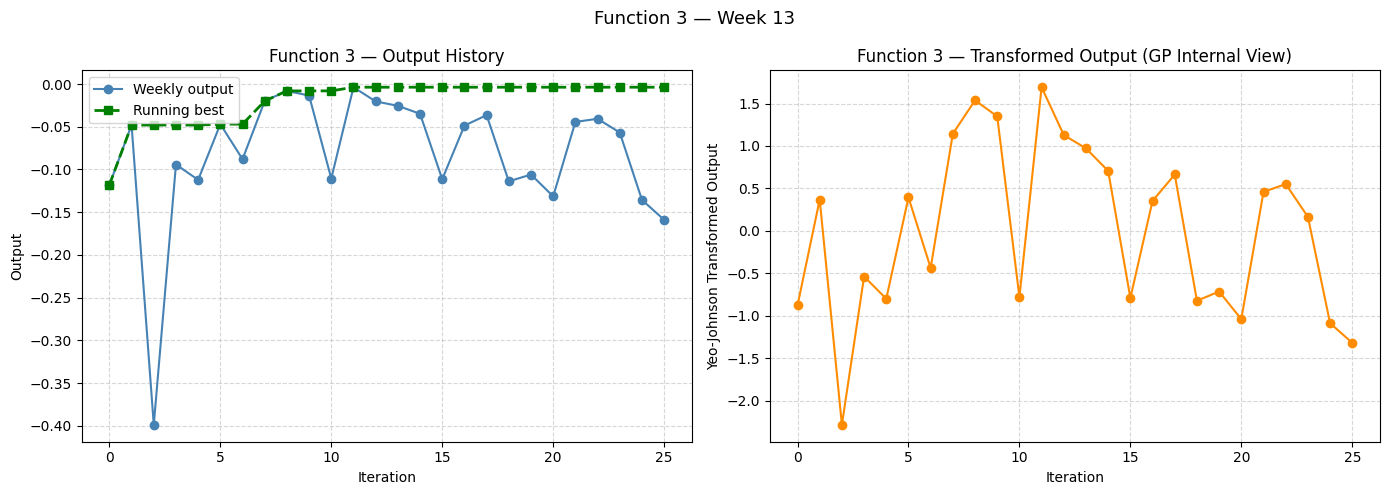

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].set_title('Function 3 — Output History')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Output')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(Y_transformed, marker='o', color='darkorange', linewidth=1.5)
axes[1].set_title('Function 3 — Transformed Output (GP Internal View)')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Yeo-Johnson Transformed Output')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 3 — Week 13', fontsize=13)
plt.tight_layout()
plt.show()